### drifting the integrable Harper model, not chaotic

In [1]:
import numpy as np

import matplotlib.pyplot as plt
#from scipy.integrate import odeint
import mpmath as mpmath
import scipy
from scipy.optimize import linear_sum_assignment

# %matplotlib notebook 
%matplotlib inline 

import Husimi   # Quantum routines
import Harp     # Classical integration routines
import importlib  # for reloading routines if you need to edit them

In [ ]:
# if higher precision with mpmath 
# https://mpmath.org/
# https://mpmath.org/doc/current/matrices.html

# less relevant I think:
# this! https://github.com/c-f-h/flamp
# https://pypi.org/project/gmpy2/

In [2]:
import mpmath  # it is already installed!

In [3]:
mpmath.libmp.BACKEND   # I installed gmpy so it would be faster!

'gmpy'

In [4]:
print(mpmath.mp)

Mpmath settings:
  mp.prec = 53                [default: 53]
  mp.dps = 15                 [default: 15]
  mp.trap_complex = False     [default: False]


In [5]:
mpmath.mp.dps=50  # more decimal places, precission set here
print(mpmath.mp)

Mpmath settings:
  mp.prec = 169               [default: 53]
  mp.dps = 50                 [default: 15]
  mp.trap_complex = False     [default: False]


In [6]:
# to use it I have to write a special routine to fill h0 with all numbers that are specified by mpmath

In [7]:
# create a high precission version of h0
def h0_prec(n,a,b,eps):
    fac = mpmath.fdiv(mpmath.fmul(2,mpmath.pi),mpmath.mpf(int(n)))  # 2*pi/N
    h0 = mpmath.zeros(int(n)) # not complex 
    for j in range(int(n)):
        phij = mpmath.fmul(fac,mpmath.mpf(j))
        ke = mpmath.fsub(mpmath.fmul(mpmath.cos(phij),mpmath.cos(mpmath.mpf(b))),\
                         mpmath.fmul(mpmath.sin(phij),mpmath.sin(mpmath.mpf(b))))
        h0[j,j] = mpmath.fmul(mpmath.mpf(eps),ke)
    for j in range(int(n)):
        h0[j,(j+1)%int(n)] = mpmath.fdiv(mpmath.mpf(a),mpmath.mpf(2))
        h0[(j+1)%int(n),j] = mpmath.fdiv(mpmath.mpf(a),mpmath.mpf(2))
    return h0 *mpmath.mpf(-1) 

# get eigenvalues and sort them in order of energy 
# using precision routines!
def h0_prec_eigs(n,a,b,eps):
    h0 = h0_prec(n,mpmath.mpf(a),mpmath.mpf(b),mpmath.mpf(eps)) 
    (w,vr) = mpmath.eigsy(h0) # returns real eigenvalues 
    #iphi = np.argsort(w.tolist())  # sort needs a list or array to work, this keeps mpf numbers in array
    iphi = np.argsort(np.array(w))  # sort in order of energy
    w_arr = np.array(w)
    w_sort = w_arr[iphi]  # sorted energies, is a sorted array of mpfs 
    vr_arr = np.array(vr)  # is 1d
    vr_arr = np.reshape(vr_arr, (n,n)) # is 2d now
    vrsort = vr_arr[:,iphi] # sorted eigenvectors now 2d array of mpfs
    return w_sort,vrsort

#n=3 # tests 
#h0 = h0_prec(n,mpmath.mpf(1),mpmath.mpf(0),mpmath.mpf(0.1)) 
#(w,vr) = mpmath.eigsy(h0)  #let's see if this works
#iphi = np.argsort(np.array(w))
#w_arr = np.array(w)
#w_sort = w_arr[iphi]

(w,vr)= h0_prec_eigs(3,1.,mpmath.mpf(0),mpmath.mpf(0.1)) 

In [8]:
importlib.reload(Husimi)  # if you need to reload it!

<module 'Husimi' from '/Users/aquillen/Desktop/summer24/pylab/QDrift/Husimi.py'>

In [9]:
importlib.reload(Harp)  # if you need to reload it!

<module 'Harp' from '/Users/aquillen/Desktop/summer24/pylab/QDrift/Harp.py'>

In [10]:
# for each eigenvalue in a list compute the distance to the nearest other one
# this routine uses mpmath
def min_de_vec(w_vec):
    n = len(w_vec)
    de_single_arr = np.zeros(n)
    for j in range(n):  # loop over eigenvalues 
        w = np.copy(w_vec)
        w[j] = mpmath.mpf(1e10)  # set its own eigenvalue to something ridiculously large so it won't contribute
        min_de = np.min(np.abs(w - w_vec[j]))  # not sure how to do this with mpmath 
        de_single_arr[j] = min_de
        #print(min_de)
    return de_single_arr

In [11]:
# sweep over n, return energies and de to nearest eigenvalues
# high precision version 
def n_de_sweep(eps,btype,nmin,nmax):
    wlist = []
    nlist = []
    delist = []

    a=mpmath.mpf(1.0)
    for k in range(nmin,nmax):
        n = k;  
        if (btype == 0):
            b = mpmath.mpf(0)
        else:
            b = mpmath.fdiv(mpmath.pi, mpmath.mpf(int(n)))
        n_arr = np.ones(n)*n # a list with n's in it
        nlist = np.append(nlist,n_arr)
        #(w,vr) = Husimi.h0_eigs(n,a,b,eps) # return eigenvalues, sorted in order of energy
        (w,vr) = h0_prec_eigs(n,a,b,eps) # try the precision version!
        wlist = np.append(wlist,w)  # was w-1
        de_vec = min_de_vec(w)
        delist = np.append(delist,de_vec)
    return nlist,wlist,delist
        

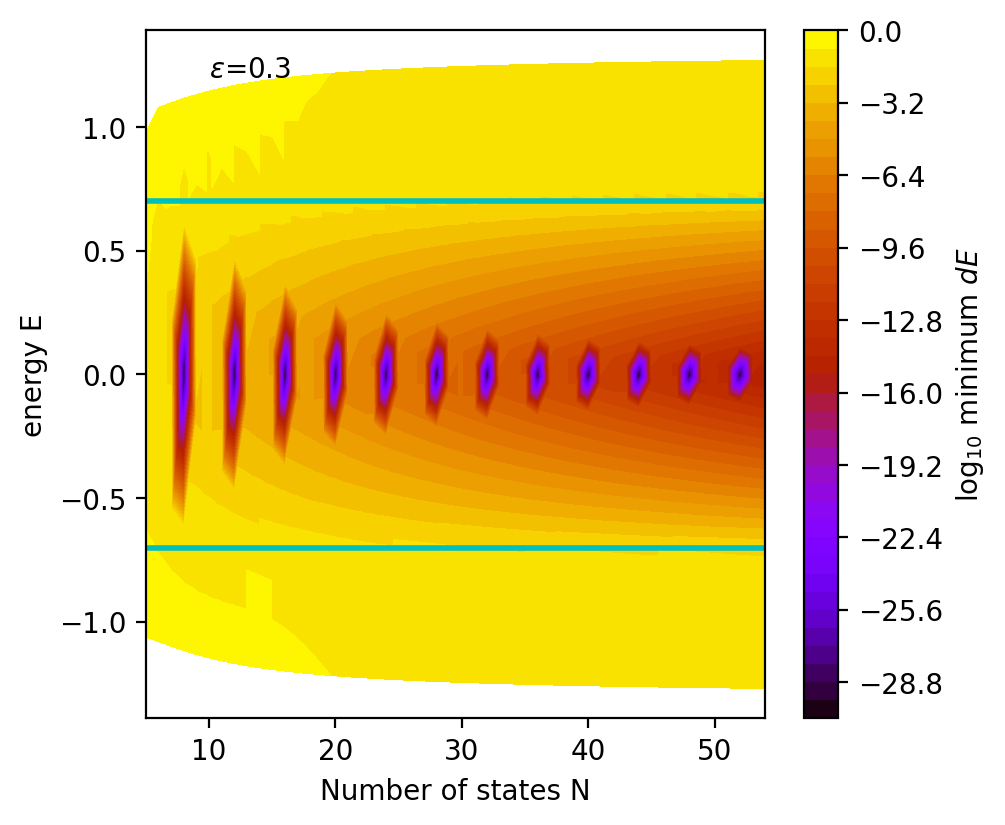

In [12]:
# makes a figure, given list of eigenvalues and nearest energy spacings 
def mkcontour_sweep(eps,nmin,nmax,nlist,wlist,delist,minimum_number,ofile):
    fig,ax = plt.subplots(1,1,figsize=(4.5,4),dpi=200)
    plt.subplots_adjust(left=0.12,top=0.98,right=0.98,bottom=0.12)
    #minimum_number = 1e-30
    delist_log = np.log10(delist+minimum_number)
    #ax.tricontour(nlist, wlist, delist_log, levels=14, linewidths=0.5, colors='k')
    cntr2 = ax.tricontourf(nlist, wlist, delist_log,  levels=40, cmap="gnuplot")
    cbar = fig.colorbar(cntr2, ax=ax)
    cbar.set_label(r'log$_{10}$ minimum $dE$')
    ax.set_xlabel('Number of states N')
    ax.set_ylabel('energy E')
    narr = np.arange(nmin,nmax)
    oarr = narr*0 + 1.0
    top = (1 - eps)*oarr
    bottom = -1*top*oarr
    ax.plot(narr,top,'c-',lw=2)
    ax.plot(narr,bottom,'c-',lw=2)
    ymax = 1+1.3*eps
    ax.set_ylim([-ymax,ymax])
    estr = r'$\epsilon$={:.1f}'.format(eps)
    ax.text(10,0.9+eps,estr)
    if (len(ofile)>3):
        plt.savefig(ofile+'.png')
    plt.show()

eps = 0.3;
nmin = 5
nmax = 55
nlist,wlist,delist = n_de_sweep(eps,0,nmin,nmax)
mkcontour_sweep(eps,nmin,nmax,nlist,wlist,delist,1e-30,'eee3')

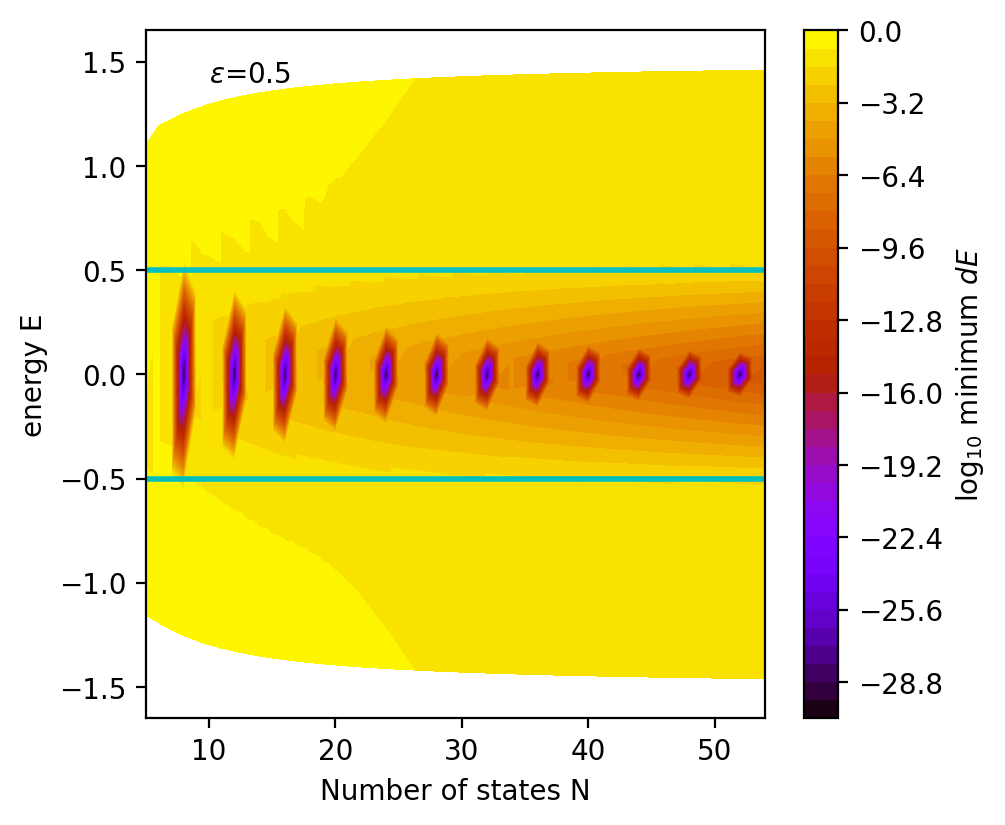

In [13]:
eps = 0.5;
nmin = 5
nmax = 55
nlist,wlist,delist = n_de_sweep(eps,0,nmin,nmax)
mkcontour_sweep(eps,nmin,nmax,nlist,wlist,delist,1e-30,'eee5')

In [14]:
# sweep over eps, return energies and de to nearest eigenvalues
# is used below!
def e_de_sweep(eps_min,eps_max,n_eps,btype,n):
    wlist = []
    eps_list = []
    delist = []
    eps_lin = np.linspace(eps_min,eps_max,n_eps)

    a=1.0
    if (btype == 0):
        b = 0.0
    else:
        b = np.pi/n
    for k in range(n_eps):
        eps = eps_lin[k]
        #(w,vr) = Husimi.h0_eigs(n,a,b,eps) # return eigenvalues, sorted in order of energy
        (w,vr) = h0_prec_eigs(n,a,b,eps) # try the precision version! sorted via energy
        wlist = np.append(wlist,w)  # was w-1
        #wlist = np.append(wlist,w-1)  #-1 here if using previous function h0_eigs
        eps_arr = np.zeros(n) + eps 
        eps_list = np.append(eps_list,eps_arr)  
        de_vec = min_de_vec(w)
        delist = np.append(delist,de_vec)
    return eps_list,wlist,delist
        

# make a figure showing a contour sweep made with above routine e_de_sweep()
# here n is number of states
# eps_list is list of epsilon values, 
# wlist, de list are energies and spacings at these epsilons
# low_lim is lower limit of de for taking log_10
def mkcontour_sweep_e(n,eps_list,wlist,delist,low_lim,ofile):
    fig,ax = plt.subplots(1,1,figsize=(4.5,4),dpi=200)
    delist_log = np.log10(delist+low_lim)
    #ax.tricontour(eps_list, wlist, delist_log, levels=14, linewidths=0.5, colors='k')
    cntr2 = ax.tricontourf(eps_list, wlist, delist_log,  levels=40, cmap="gnuplot")
    cbar = fig.colorbar(cntr2, ax=ax)
    cbar.set_label(r'log$_{10}$ minimum $dE$')
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel('energy E')
    eps_lin = np.linspace(np.min(eps_list),np.max(eps_list),20)
    top = (1 - eps_lin)
    bottom = -1*top
    ax.plot(eps_lin,top,'c-',lw=2)
    ax.plot(eps_lin,bottom,'c-',lw=2)
    ymax = 1+1.3*np.max(eps_list)
    ax.set_ylim([-ymax,ymax])
    estr = r'$N$={:.0f}'.format(n)
    ax.text(0.15,0.9+eps,estr)
    if (len(ofile)>3):
        plt.savefig(ofile+'.png')
    plt.show()


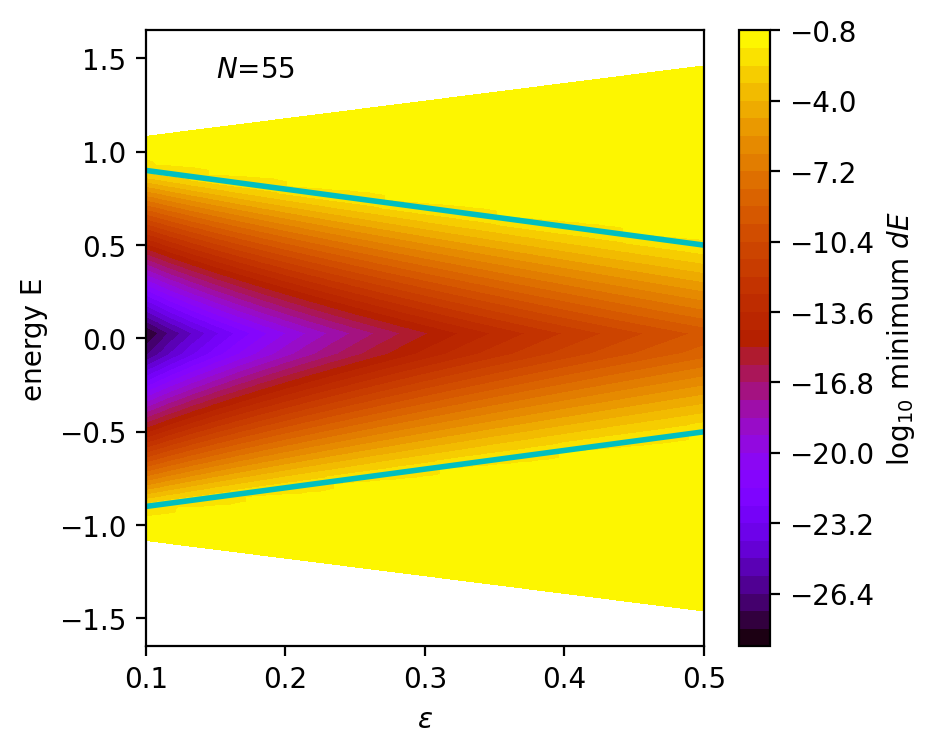

In [15]:
eps_min = 0.1
eps_max = 0.5
n_eps = 25
n=55
eps_list,wlist,delist = e_de_sweep(eps_min,eps_max,n_eps,0,n)
mkcontour_sweep_e(n,eps_list,wlist,delist,1e-30,'fff55')

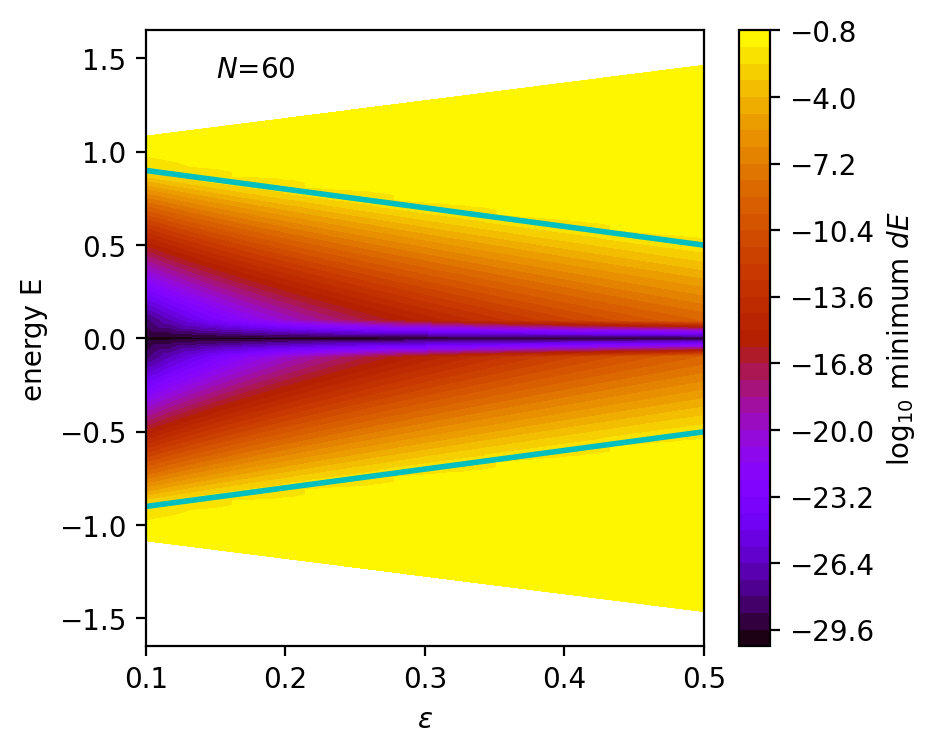

In [16]:
eps_min = 0.1
eps_max = 0.5
n_eps = 25
n=60
eps_list,wlist,delist = e_de_sweep(eps_min,eps_max,n_eps,0,n)
mkcontour_sweep_e(n,eps_list,wlist,delist,1e-30,'fff60')


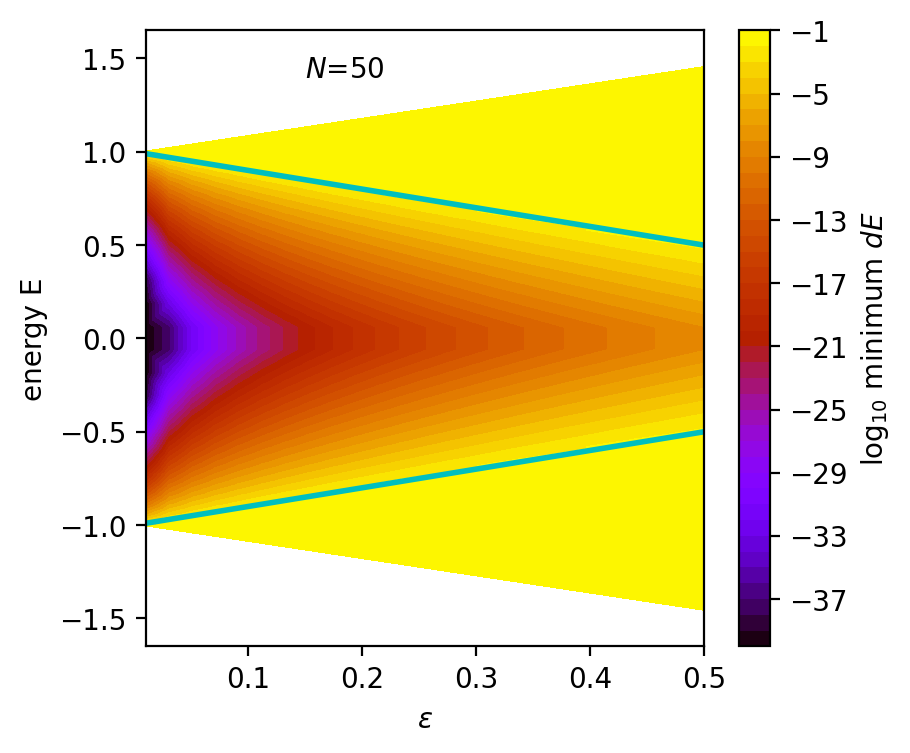

In [17]:
eps_min = 0.01
eps_max = 0.5
n_eps = 25
n=50
eps_list,wlist,delist = e_de_sweep(eps_min,eps_max,n_eps,0,n)
mkcontour_sweep_e(n,eps_list,wlist,delist,1e-40,'fff50')

In [18]:
# drift h0 slowly, nseries outputs computing instantaneous eigenvalues 
# drift rate per output is in dparms
# return sorted eigenvalues and eigenvectors, sorted in order of eigenvalue 
# uses Husimi.hat_h_0 routine for computing h0
def h0_drift(n,parms0,dparms,nseries):
    w_list = np.zeros((nseries,n),dtype=float)
    vr_list = np.zeros((nseries,n,n),dtype=complex)
    for k in range(nseries):
        parms = parms0 + dparms*k  # notice drift rate 
        a = parms[0] # note the order of the parameter list, these are current parameters
        b = parms[1]
        eps = parms[2]
        #print(parms)
        if (k==0):
            print('a_init={:.6f}, b_init={:.6f}, eps_init={:.6f}'.format(a,b,eps))  # print the parameter values at the beginning 
        #mu =  parms[3]
        #mup =  parms[4]
        h0 = Husimi.hat_h_0_with_b(n,a,b,eps)  # the hamiltonian operator h_0
        (w,vr)=scipy.linalg.eigh(h0)   # find eigenvalues and eigenvectors of hermitian op
        iphi = np.argsort(np.real(w))   # sort in order of energy 
        vrsort = vr[:,iphi]   # second index gives eigenvec
        w_list[k,:] = np.real(w[iphi]) # h_0 is Hermitian so they should be real. 
        vr_list[k,:,:] = vrsort  # sorted eigenvectors 
    print('a_final={:.6f}, b_final={:.6f}, eps_final={:.6f}'.format(a,b,eps))  # print the parameter values at the end 
    return w_list,vr_list 

# a class structure to hold drifting unperturbed system
# calls above routine h0_drift
class h0_drift_class():
    def __init__(self,n,parms0,dparms,nseries):
        self.n = n
        self.nseries = nseries
        self.parms0 = parms0
        self.dparms = dparms
        self.a_0   = parms0[0] # note the order of the parameter list, these are current parameters
        self.b_0   = parms0[1]
        self.eps_0 = parms0[2]
        self.d_a   = dparms[0]
        self.d_b   = dparms[1]
        self.d_eps = dparms[2]
        self.parms_final = parms0 + (self.nseries-1)*dparms
        self.a_final   = self.parms_final[0]
        self.b_final   = self.parms_final[1]
        self.eps_final = self.parms_final[2]
        print('parms_final', self.parms_final)

        # some vectors that display ranges 
        self.iis = np.arange(self.nseries)
        self.a_range = self.a_0 + self.d_a*self.iis 
        self.b_range = self.b_0 + self.d_b*self.iis 
        self.eps_range = self.eps_0 + self.d_eps*self.iis 
        
        # compute series of instantaneous eigenvalues and eigenvectors 
        self.w_list,self.vr_list  = h0_drift(self.n,self.parms0,self.dparms,self.nseries)    
        self.de_singles = min_de_singles(self.w_list)  # compute distance to nearest eigenvalues 
        #vr_list[k,:,:] = vrsort  # eigenvectors at time k

    def compute_U(self,T,ntau):  # compute propagator across the drift 
        self.ntau = ntau
        self.T = T
        # h0_Udrift(N,T,ntau,parms0,d_parms) # compute propagator across the drift 
        self.w_s,self.vr_s,self.U_final = h0_Udrift(self.n,T,ntau,self.parms0,self.parms_final) 
        # compute propagator across the drift 

    def compute_U2(self,T,ntau):  # compute propagator across the drift using a different routine
        self.ntau = ntau
        self.T = T
        # h0_Udrift(N,T,ntau,parms0,d_parms) # compute propagator across the drift using the other routine
        self.w_s,self.vr_s,self.U_final = h0_Udrift2(self.n,T,ntau,self.parms0,self.parms_final) 
      

# returns the closest distance to next nearest energy for each eigenvalue at each time in the series
# w_list is a series of eigenvalues 
def min_de_singles(w_list):
    nseries = w_list.shape[0]
    n = w_list.shape[1]
    de_singles_list = np.zeros([nseries,n])
    for k in range(nseries):  # each in the series 
        w_vec = np.squeeze(w_list[k,:])  # list of eigenvalues 
        for j in range(n):
            w = np.copy(w_vec)
            w[j] = 1e10   # set itself to something ridiculously large
            min_de = np.min(np.abs(w - w_vec[j]))
            de_singles_list[k,j] = min_de  # each eigenvalue has a min distance to nearest 
    return de_singles_list 
        

In [19]:
# compute separatix energy as a function of time 
# consistent with h0 defined in Husimi.py
def sep_energy(h0class):
    #a_vec = h0class.parms0[0] + h0class.dparms[0] * h0class.iis
    #eps_vec = h0class.parms0[2] + h0class.dparms[2] * h0class.iis
    top = 2*h0class.a_range - h0class.eps_range
    bottom = h0class.eps_range 
    return bottom,top  # separatrix energies as a function of time

from matplotlib import colors

# make a figure showing eigenvalues for a drifting series 
# energy is shifted by a but not flipped 
# color shows distance to nearest eigenvalue
def show_eigs(h0class,i0,i1,ymin,ymax,ofile):
    #i0=0;i1=nseries typically for entire range
    shift_E = True
    fig,ax = plt.subplots(1,1,figsize=(5,4),dpi=300)
    n  = h0class.n 
    
    if (h0class.d_b ==0):
        xx = h0class.eps_range[i0:i1]
        ax.set_xlabel(r'resonance strength $\epsilon$')
    else:
        xx = h0class.b_range[i0:i1]
        ax.set_xlim([np.min(h0class.b_range[i0:i1]),np.max(h0class.b_range[i0:i1])])
        ax.set_xlabel(r'resonance center $b$')

    if (h0class.d_b !=0) and (h0class.d_eps ==0):
        fac = np.pi/n
        ax2 = ax.twiny()
        ax2.set_xlim([np.min(h0class.b_range[i0:i1])/fac,np.max(h0class.b_range[i0:i1])/fac])
        ax2.set_xlabel(r'$bN/\pi$')

    if (h0class.d_b !=0) and (h0class.d_eps !=0):
        ax2 = ax.twiny()
        ax2.set_xlim([np.min(h0class.eps_range[i0:i1]),np.max(h0class.eps_range[i0:i1])])
        ax2.set_xlabel(r'resonance strength $\epsilon$')
        
    bottom,top = sep_energy(h0class)
    if (shift_E == True): # notice shift in energy!
        ax.plot(xx, bottom[i0:i1] - h0class.a_0,'r:',alpha=0.3,label='separatrix') # separatrix vals
        ax.plot(xx, top[i0:i1] - h0class.a_0 ,'r:',alpha=0.3)
    else: 
        ax.plot(xx, bottom[i0:i1] ,'r:',alpha=0.3,label='separatrix') # separatrix vals
        ax.plot(xx, top[i0:i1] ,'r:',alpha=0.3)
    
        
    colormap = plt.cm.viridis #or any other colormap
    normalize = colors.Normalize(vmin=-8, vmax=-0.3)

    for k in range(n):
        if (shift_E == True): # notice shift in energy!
            yy = np.squeeze(h0class.w_list[i0:i1,k]) - h0class.a_0   # notice shift in energy here!!!!!
        else: 
            yy = np.squeeze(h0class.w_list[i0:i1,k])   # no shift in energy here!!!!!
            
        de = np.squeeze(np.log10(h0class.de_singles[i0:i1,k] + 1e-9))
        #ax.plot(xx, yy, 'k-',lw=0.5,alpha=0.5) 
        ss = ax.scatter(xx, yy, c=de, s=0.2, cmap=colormap, norm=normalize, marker='.')

    ax.set_ylim([ymin,ymax])
    ax.set_ylabel('Eigenvalues')
    #plt.colorbar(ss)

    cbar = fig.colorbar(ss, ax=ax)
    cbar.set_label(r'log$_{10}$ minimum $dE$')

    ax.text(0.2,0,'circulating')
    xl = 0.75*(np.max(xx) - np.min(xx)) + np.min(xx)
    ax.text(xl,1,'librating')
    ax.text(xl,-1,'librating')
    ax.legend(loc='upper left')

    nstr = 'N={:d}'.format(n)
    ax.text(0.05, 0.05, nstr, horizontalalignment='left',\
        verticalalignment='center', transform=ax.transAxes)

    if (len(ofile)>2):
        outfile = ofile + '_h0drift.png'
        plt.savefig(outfile)
        print(outfile)

    plt.show()


In [20]:
# drift h0 from t=0 to t=T, by creating a propagator!
# U = e^int_0^T -ih_0(t) dt time ordered 
# N is dimension
# parms0 are [a,b,epsilon] at t=0
# parms_final are final values of the parameters 
# ntau is number of divisions in time for Trotterization
def h0_Udrift(N,T,ntau,parms0,parms_final):
    #DLambda_B =np.zeros((N,N),dtype=complex)  # storing diagonal matrix for phi part

    #diagonals  used in construction 
    #Dc= np.zeros(N,dtype=complex)
    #Ds= np.zeros(N,dtype=complex)
    
    dtau = T/ntau  # step size for time 
    d_parms = (parms_final - parms0)/T # drift rate
    
    Q_FT,Q_FT_dagger = Husimi.QFT(N)  # need only be computed once, Fourier transform matrices

    #create some diagonals ahead of time, these are 1d arrays
    kvec = np.arange(N)  #integers from 0 to N-1
    pkvec = 2*np.pi*kvec/N  # frequencies or angles 
    Dc = np.cos(pkvec)
    Ds = np.sin(pkvec)
    phivec = pkvec # is the same thing really giving 2*np*j/N

    Efac = dtau  # here taking hbar = 1

    # half step at the beginning 
    parms = parms0 
    a = parms[0]; b = parms[1]; epsilon= parms[2]
    D_Ah = np.diag(np.exp(-0.5j*Efac*a*(1.0 - Dc*np.cos(b) - Ds*np.sin(b)))) # exp works on each element of the array 
    # half step in Fourier basis 
    LAh  = np.matmul(Q_FT,np.matmul(D_Ah ,Q_FT_dagger))  # put into phi basis 
    U_final = LAh;

    for i in range(ntau): # each dtau
        tau = i*dtau  # time of propagator 
        parms = parms0 + d_parms*tau # parameters at each time!
        a = parms[0] # note the order of the parameter list, these are current parameters
        b = parms[1] 
        eps = parms[2]
        # full step, this is a*(1- cos (p-b)), because of -1
        D_A = np.diag(np.exp(-1j*Efac*a*(1.0 - Dc*np.cos(b) - Ds*np.sin(b)))) # create a diagonal matrix 
        LA = np.matmul(Q_FT,np.matmul(D_A ,Q_FT_dagger)) #FT into phi basis 
        # create the diagonal operator for -eps cos phi
        D_B_diag = np.exp(1j*Efac*eps*np.cos(phivec))
        # note sign of 1j (-1 * -1 = 1), 1=fullstep
        DLambda_B = np.diag(D_B_diag) # create a matrix now from the diagonal 

        U_final = np.matmul(LA,np.matmul(DLambda_B,U_final)) # mult by B and then A, full steps

    # inverse half step
    parms = parms0 + d_parms*(T - dtau)
    a = parms[0];  b = parms[1];  eps = parms[2]
    # is a half inverse step because of 0.5  
    D_Ah_inv = np.diag(np.exp(0.5j*Efac*a*(1.0-Dc*np.cos(b) - Ds*np.sin(b)))) # is a matrix
    LAh_inv     = np.matmul(Q_FT,np.matmul(D_Ah_inv ,Q_FT_dagger)) # now go back into phi basis 
    # apply inverse half step 
    U_final = np.matmul(LAh_inv,U_final)
    print('h0_Udrift: parms final ', parms);
    
    (w,vr)=scipy.linalg.eig(U_final)  # get eigenvalues and eigenvectors, use eig (not hermitian)
    w_s,vr_s = Husimi.esort_phase(w,vr)   # sort in order of increasing eigenvalue phase
    return w_s,vr_s,U_final  # w_s are phases of the propagator, and vr_s are the eigenvalues 

# another way to do the same thing as above routine
#import scipy
def h0_Udrift2(N,T,ntau,parms0,parms_final):
    dtau = T/ntau  # step size for time 
    d_parms = (parms_final - parms0)/T # drift rate
    Efac = dtau  # here taking hbar = 1

    U_final= np.identity(N,dtype=complex)
    
    for i in range(ntau): # each dtau
        tau = i*dtau  # time of propagator 
        parms = parms0 + d_parms*tau # parameters at each time!
        a = parms[0] # note the order of the parameter list, these are current parameters
        b = parms[1] 
        eps = parms[2]
        #print(parms)
        h0 = Husimi.hat_h_0_with_b(N,a,b,eps)
        dU = scipy.linalg.expm(-1j*h0*Efac)   #e^{-(i/hbar) H dt}
        U_final = np.matmul(dU,np.copy(U_final))

    (w,vr)=scipy.linalg.eig(U_final)  # get eigenvalues and eigenvectors, U is not hermitian so use eig
    w_s,vr_s = Husimi.esort_phase(w,vr)   # sort in order of increasing eigenvalue phase
    return w_s,vr_s,U_final  # w_s are phases of the propagator, and vr_s are the eigenvalues 
        


In [48]:
# take the propagator and compute transition matrices of 
#   amplitudes and phases  of <v_i|U_trans|v_j>   
#   |v_i> , eigenvecs of h0 at first time 
#   |v_j>,  eigenvecs of h0 at final time
#    U_trans is the propagator 
# arguments:  
#    drift class hclass  
def comp_trans_h0(hclass):
    #vr_first = np.squeeze(hclass.vr_list[0,:,:])  # eigenvecs of h0 at first time
    #vr_last  = np.squeeze(hclass.vr_list[hclass.nseries-1,:,:])   # eigenvecs of h0 at last time
    #U_trans = hclass.U_final   # propagator 
    
    #n = vr_first.shape[0]
    n = hclass.vr_list.shape[1]
    t_matrix = np.zeros((n,n))  # for storing amplitudes 
    p_matrix = np.zeros((n,n))  # for storing phases 
    for i in range(n):
        #v = np.squeeze(vr_first[:,i]) # i-th eigenvector of first set
        v = np.squeeze(hclass.vr_list[0,:,i]) # i-th eigenvector of first set
        for j in range(n):
            #u = np.squeeze(vr_last[:,j])  # j-th eigenvector of last set
            u = np.squeeze(hclass.vr_list[hclass.nseries-1,:,j])  # j-th eigenvector of last set
            uUv = np.vdot(u,np.matmul(hclass.U_final,v))   # compute <u|U_trans|v>
            t_matrix[i,j] = np.abs(uUv) # compute magnitude and put it in a matrix 
            p_matrix[i,j] = np.angle(uUv) # compute phase and put it in a matrix 
    return t_matrix,p_matrix 

# same as above routine except using matrices of eigenvecs directly 
def comp_trans_uUv(vr2,U,vr1):
    n = vr1.shape[0]
    t_matrix = np.zeros((n,n))  # for storing amplitudes 
    p_matrix = np.zeros((n,n))  # for storing phases 
    for i in range(n):
        v = np.squeeze(vr1[:,i]) # i-th eigenvector of first set
        for j in range(n):
            u = np.squeeze(vr2[:,j])  # j-th eigenvector of last set
            uUv = np.vdot(u,np.matmul(U,v))   # compute <u|U_trans|v>
            t_matrix[i,j] = np.abs(uUv) # compute magnitude and put it in a matrix 
            p_matrix[i,j] = np.angle(uUv) # compute phase and put it in a matrix 
    return t_matrix,p_matrix 


# plots two matrices one next to another, both need to be real 
# with colorbars on both sides 
def plt2_trans(t_matrix,p_matrix,ofile):
    fig,axarr = plt.subplots(1,2,figsize=(4,2),sharex=True,sharey=True,dpi=200)
    plt.subplots_adjust(hspace=0,wspace=0)
    axarr[0].set_xticks([])
    axarr[0].set_yticks([])
    axarr[1].set_xticks([])
    axarr[1].set_yticks([])
    im0 = axarr[0].imshow(t_matrix,origin='lower',cmap='viridis')
    im1 = axarr[1].imshow(p_matrix,origin='lower',cmap='twilight')  # cyclic colormap
    cax0=fig.add_axes([0.055,0.13,0.02,0.5])
    cax1=fig.add_axes([0.95,0.13,0.02,0.5])
    cbar0 = plt.colorbar(im0,cax=cax0,location='left')  
    cbar1 = plt.colorbar(im1,cax=cax1) 
    if (len(ofile)>3):
        plt.savefig(ofile)
    plt.show()


# all checks with no drift passed, perpendicularity passed, dot -> vdot was the problem 
# and order of <u U v> was corrected in comp_trans

parms_final [1.        0.0961712 0.5      ]
a_init=1.000000, b_init=0.032057, eps_init=0.500000
a_final=1.000000, b_final=0.096171, eps_final=0.500000


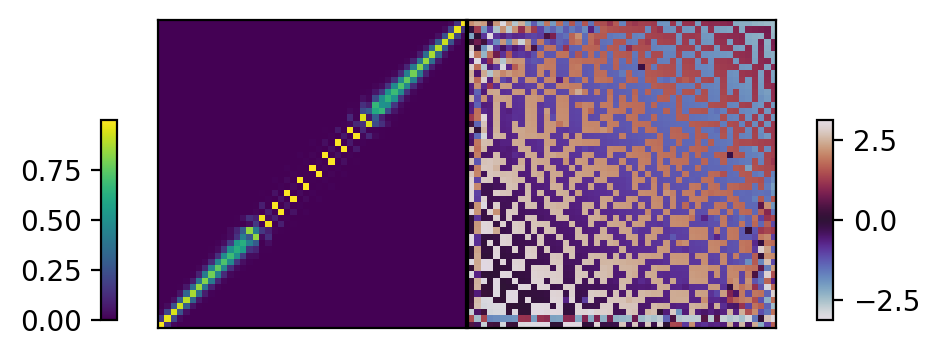

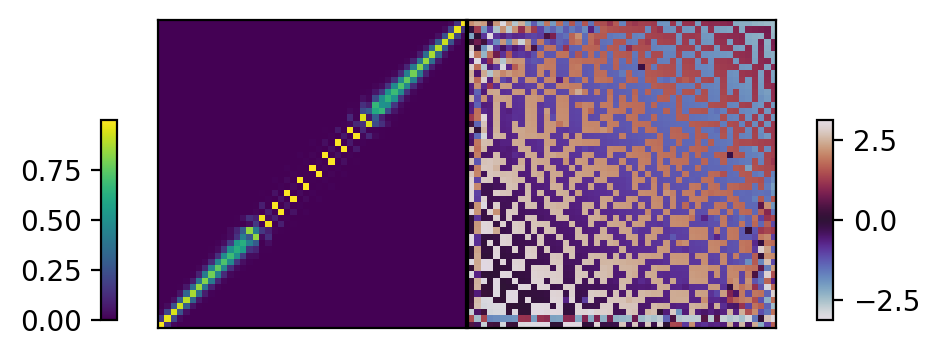

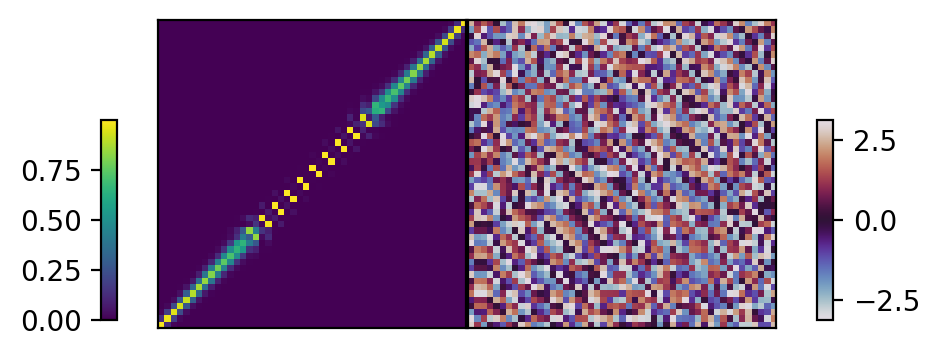

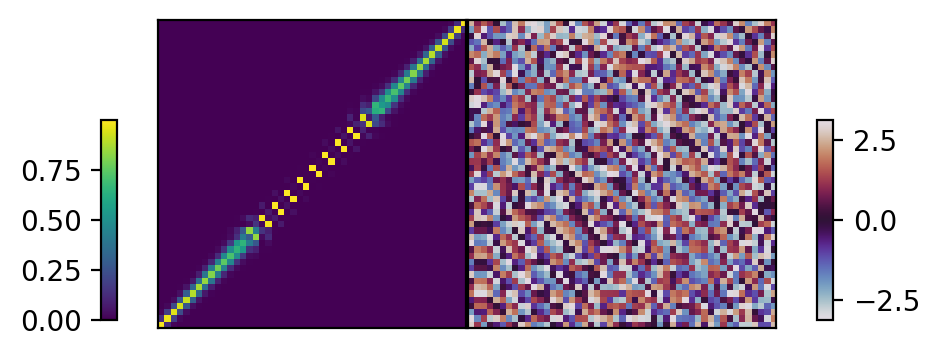

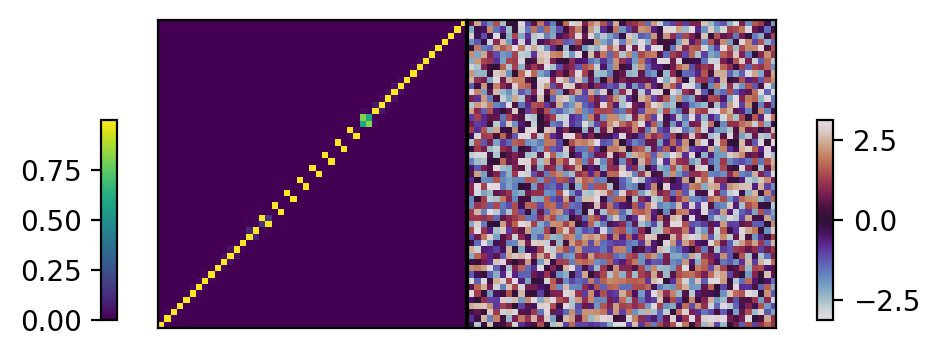

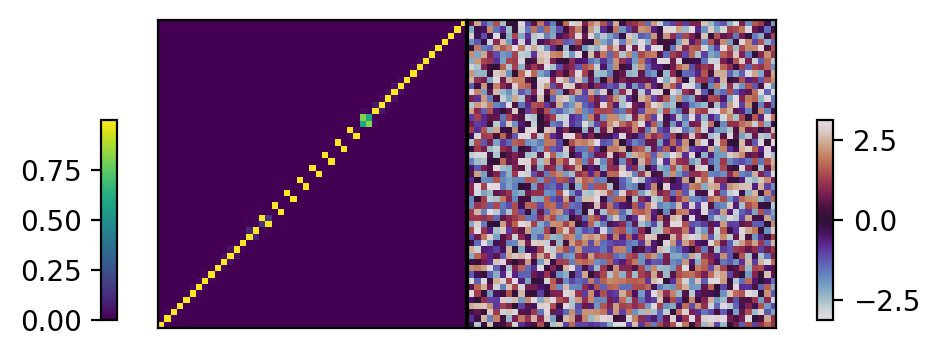

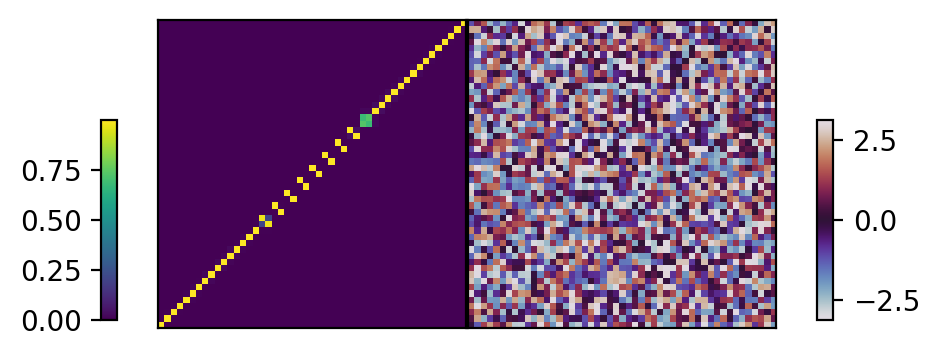

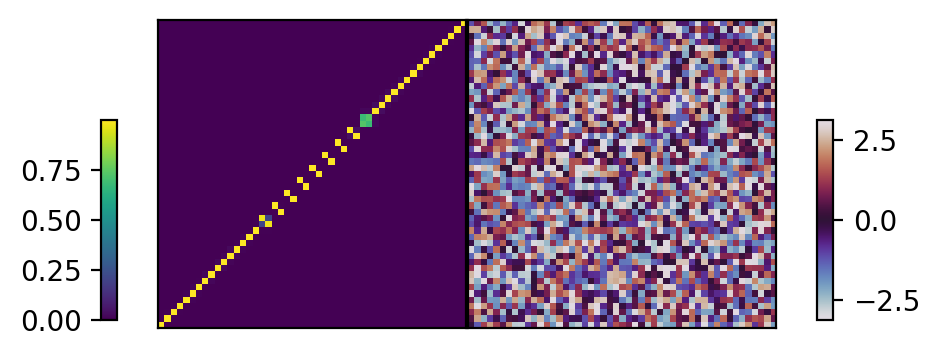

In [44]:
# only varying b 
# if only b varies, then energy levels in librating region slightly oscillate but those
# in circulating region move around and transition diabatically. 

n=49; a=1.0; eps=0.500; b=0.5*np.pi/n; parms0 = np.array([a,b,eps])
nseries=100
d_a = 0.0; 
d_b = (np.pi/n)/(nseries-1) ;  
d_eps = 0.0/(nseries-1); 
dparms = np.array([d_a,d_b,d_eps])
yy2   = h0_drift_class(n,parms0,dparms,nseries)

Tlin = np.array([1,20,400,800])

for i in range(len(Tlin)):
    T = Tlin[i]; ntau =500
    yy2.compute_U2(T,ntau)
    t_matrix,p_matrix = comp_trans_h0(yy2)
    plt2_trans(t_matrix,p_matrix,'')
    vr_first = np.squeeze(yy2.vr_list[0,:,:])
    vr_last = np.squeeze(yy2.vr_list[nseries-1,:,:])
    t_matrix,p_matrix = comp_trans_uUv(vr_last,yy2.U_final,vr_first)   # check other way to compute the transitions
    plt2_trans(t_matrix,p_matrix,'')

# everything looks ok! tests passed!

parms_final [1.         0.03205707 0.5       ]
a_init=1.000000, b_init=0.032057, eps_init=0.500000
a_final=1.000000, b_final=0.032057, eps_final=0.500000


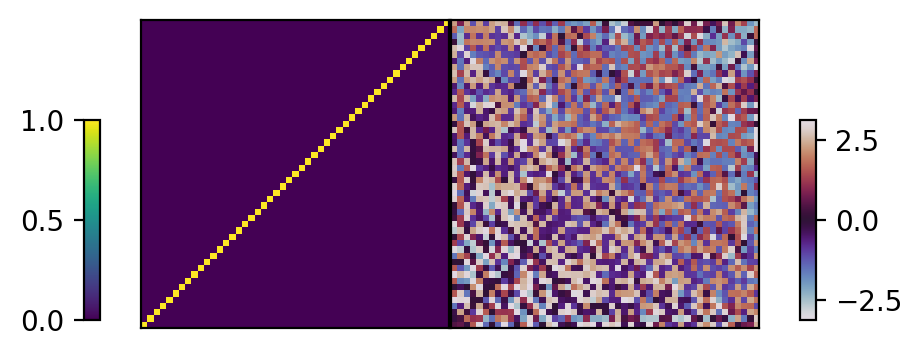

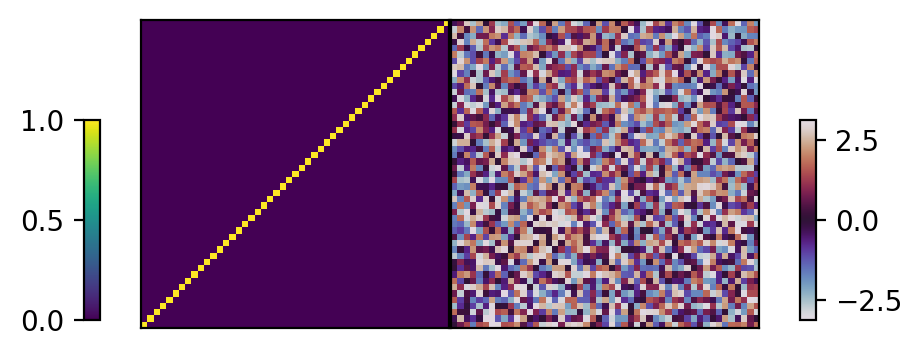

In [46]:
# only varying b 
# if only b varies, then energy levels in librating region slightly oscillate but those
# in circulating region move around and transition diabatically. 

n=49; a=1.0; eps=0.500; b=0.5*np.pi/n; parms0 = np.array([a,b,eps])
nseries=100
d_a = 0.0; 
d_b = 0*(np.pi/n)/(nseries-1) ;  
d_eps = 0.0/(nseries-1); 
dparms = np.array([d_a,d_b,d_eps])
yy2   = h0_drift_class(n,parms0,dparms,nseries)

Tlin = np.array([1,400])

for i in range(len(Tlin)):
    T = Tlin[i]; ntau =500
    yy2.compute_U2(T,ntau)
    t_matrix,p_matrix = comp_trans_h0(yy2)
    plt2_trans(t_matrix,p_matrix,'')

In [ ]:
# checks passed!

parms_final [1.         1.91701266 0.5001    ]
a_init=1.000000, b_init=0.000000, eps_init=0.000100
a_final=1.000000, b_final=1.917013, eps_final=0.500100
xx1_h0drift.png


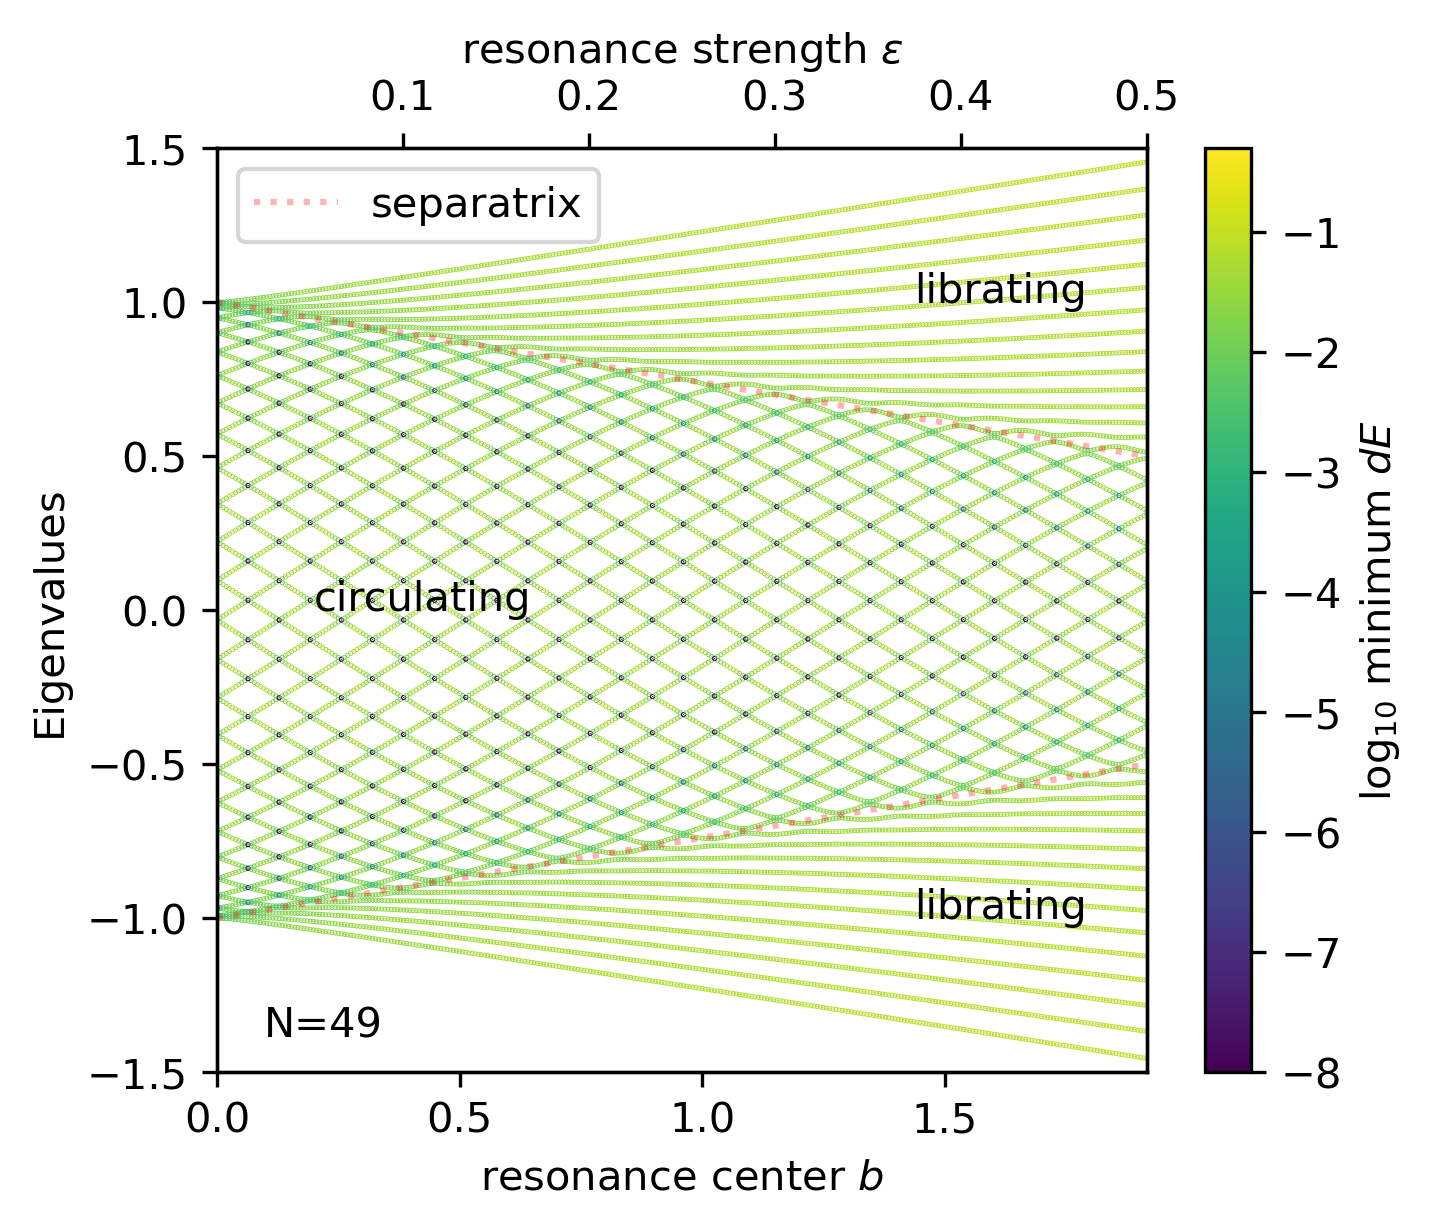

In [382]:
n=49; a=1.0; eps=0.0001; b=0.0; parms0 = np.array([a,b,eps])
nseries=300
d_a = 0.0; d_b = (2*np.pi/n)/20 ; d_eps = 0.5/(nseries-1); 
dparms = np.array([d_a,d_b,d_eps])
xx1   = h0_drift_class(n,parms0,dparms,nseries)
ymin = -1.5; ymax = 1.5
show_eigs(xx1,0,xx1.nseries,ymin,ymax,'xx1')

parms_final [1.         0.         0.99676667]
a_init=1.000000, b_init=0.000000, eps_init=0.000100
a_final=1.000000, b_final=0.000000, eps_final=0.996767
xx2_h0drift.png


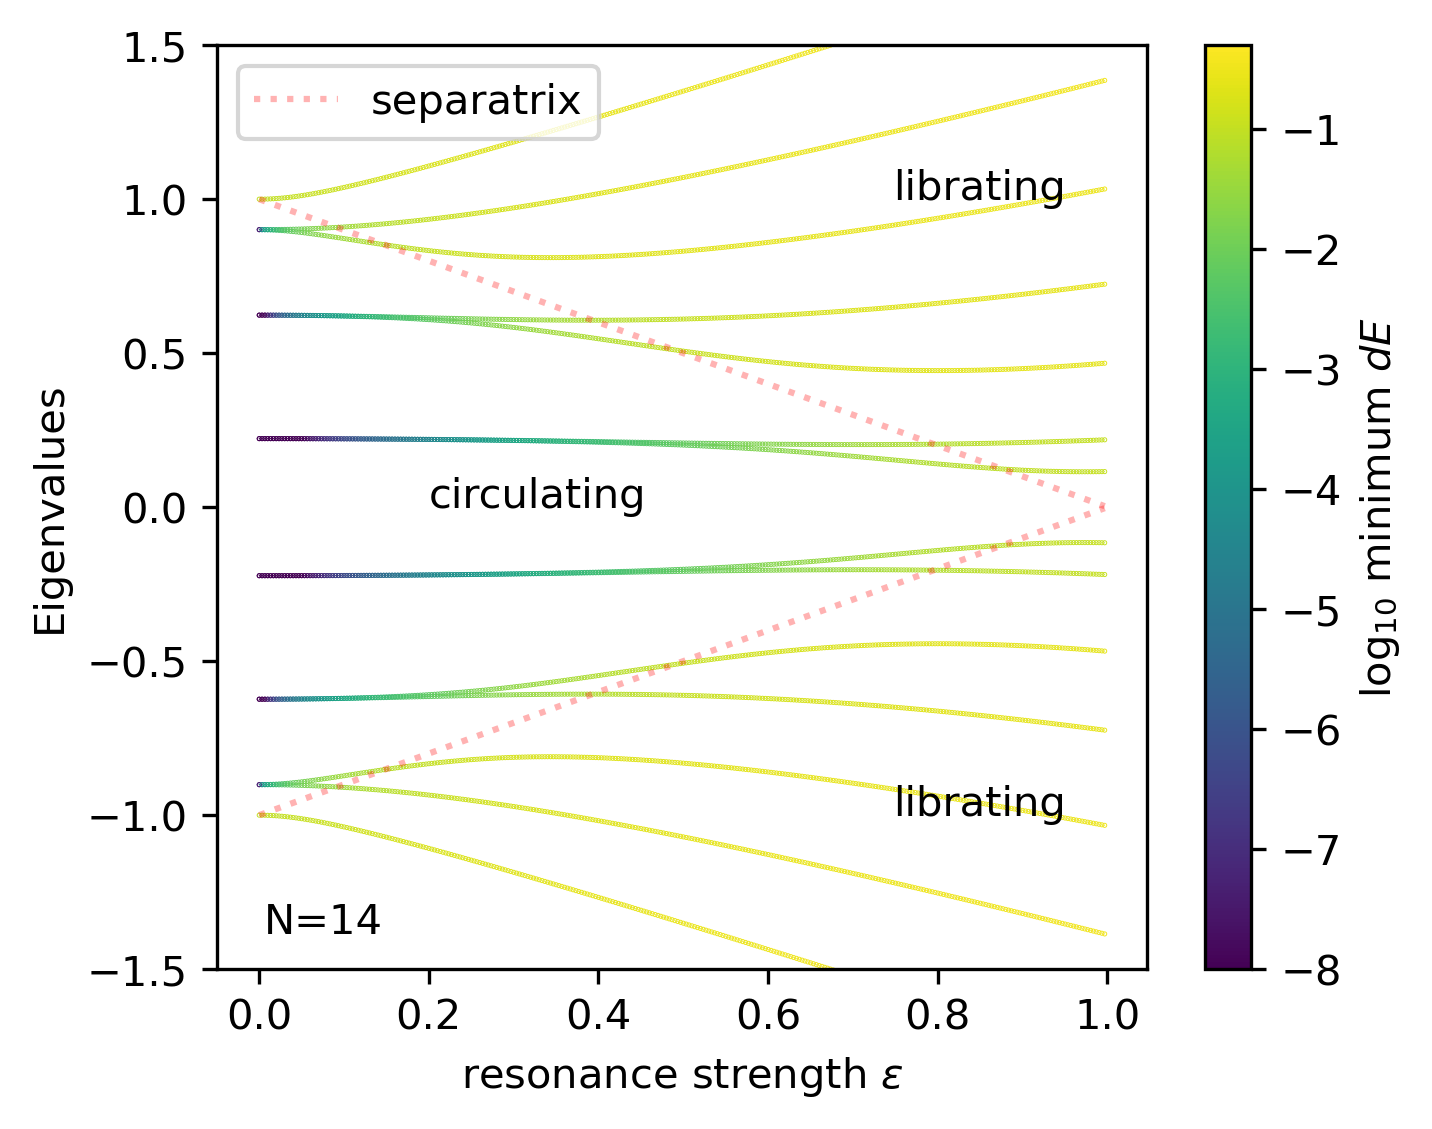

In [383]:
n=14; a=1.0; eps=0.0001; b=0.0; parms0 = np.array([a,b,eps])
nseries=300
d_a = 0.0; d_b = 0 ; d_eps = 1.0/nseries; 
dparms = np.array([d_a,d_b,d_eps])
xx2   = h0_drift_class(n,parms0,dparms,nseries)
ymin = -1.5; ymax = 1.5
show_eigs(xx2,0,xx2.nseries,ymin,ymax,'xx2')

parms_final [1.         0.62622414 0.3       ]
a_init=1.000000, b_init=0.000000, eps_init=0.300000
a_final=1.000000, b_final=0.626224, eps_final=0.300000
xx3_h0drift.png


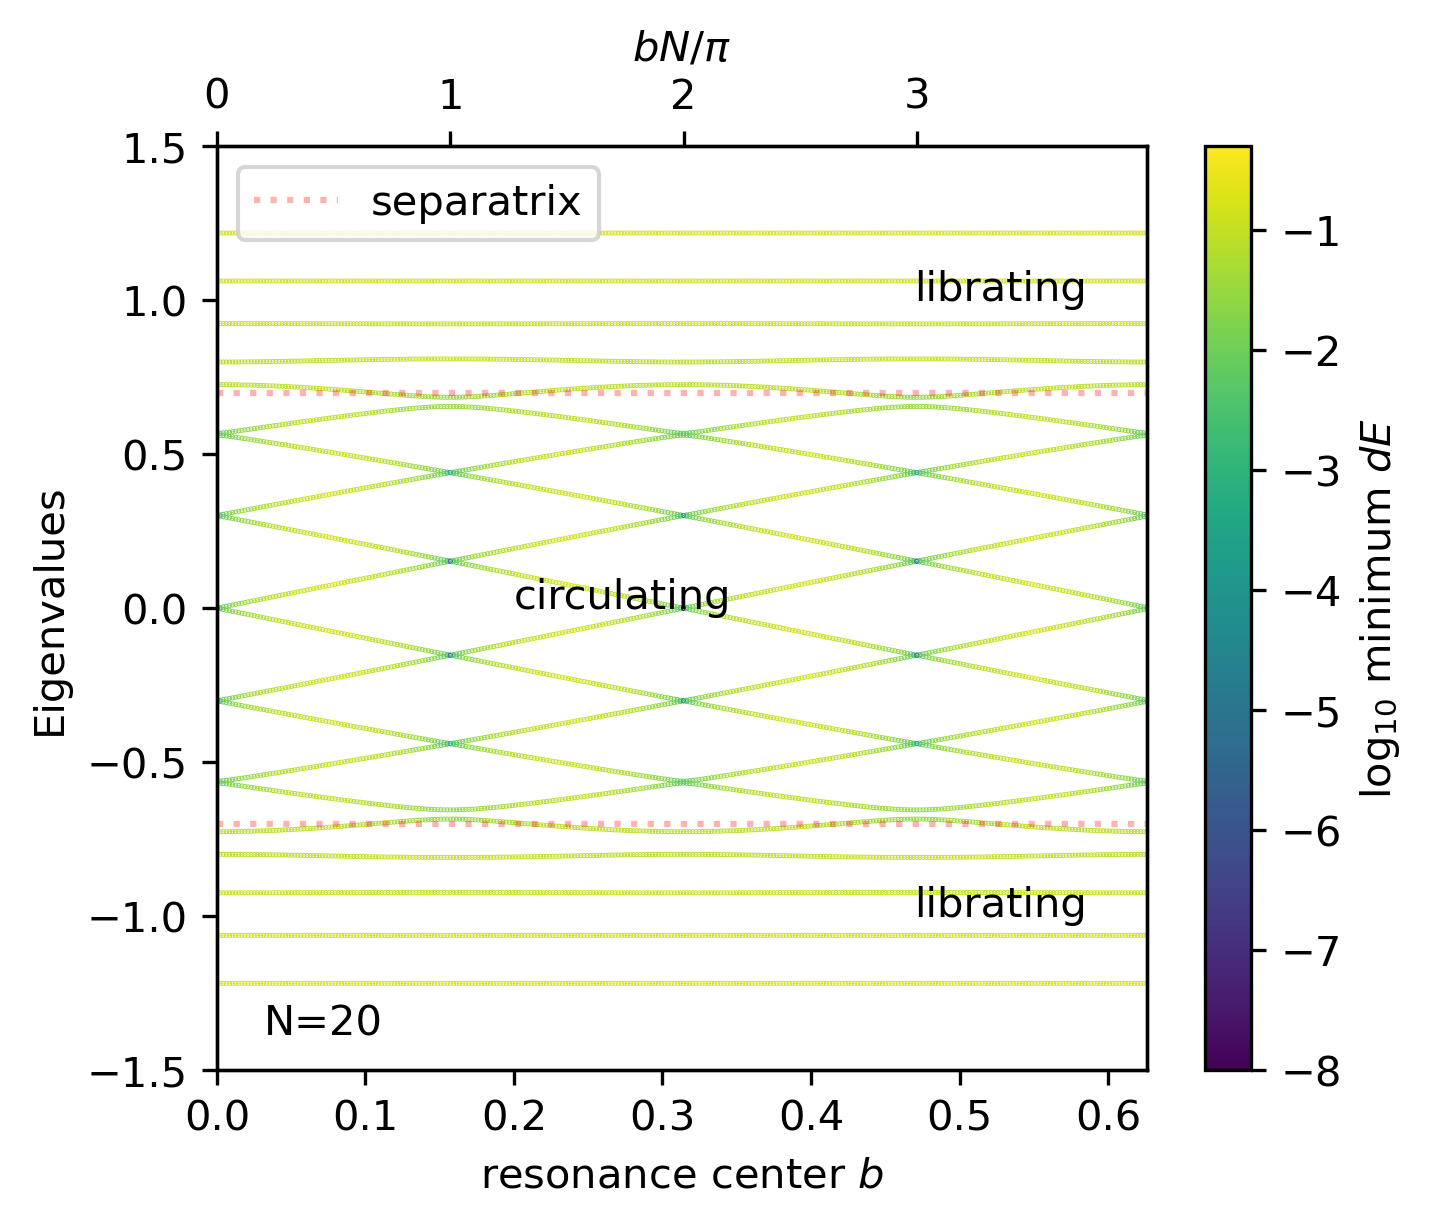

In [384]:
n=20; a=1.0; eps=0.3; b=0.0; parms0 = np.array([a,b,eps])
nseries=300
d_a = 0.0; d_b = (np.pi/n)*4/nseries ; d_eps = 0.0/nseries; 
dparms = np.array([d_a,d_b,d_eps])
xx3   = h0_drift_class(n,parms0,dparms,nseries)
ymin = -1.5; ymax = 1.5
show_eigs(xx3,0,xx3.nseries,ymin,ymax,'xx3')

parms_final [1.  0.  0.5]
a_init=1.000000, b_init=0.000000, eps_init=0.000000
a_final=1.000000, b_final=0.000000, eps_final=0.500000
h0_Udrift: parms final  [1.         0.         0.49916667]


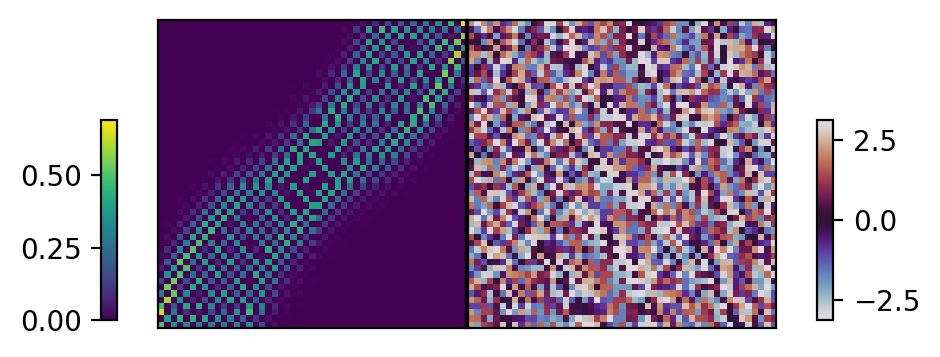

h0_Udrift: parms final  [1.         0.         0.49916667]


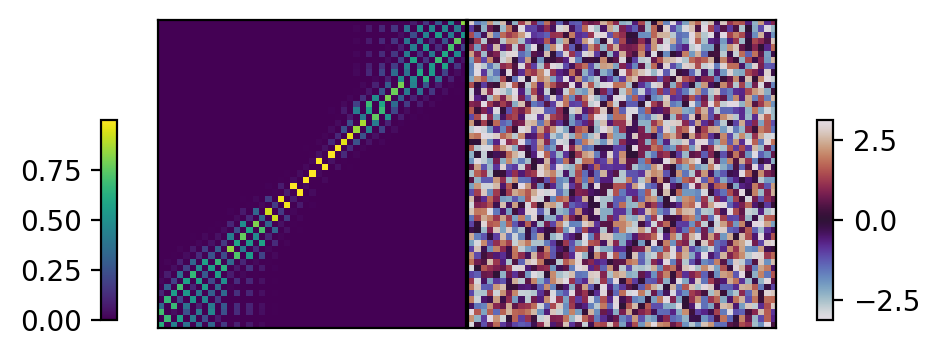

In [49]:
n=49; a=1.0; eps=0.000; b=0.0; parms0 = np.array([a,b,eps])
nseries=100
d_a = 0.0; 
d_b = 0*(2*np.pi/n)/20 ;   # drifting both b and eps
d_eps = 0.5/(nseries-1); 
dparms = np.array([d_a,d_b,d_eps])
yy1   = h0_drift_class(n,parms0,dparms,nseries)

Tlin = np.array([10,100])

for i in range(len(Tlin)):
    T = Tlin[i]; ntau =600
    yy1.compute_U(T,ntau)
    t_matrix,p_matrix = comp_trans_h0(yy1)
    plt2_trans(t_matrix,p_matrix,'')

parms_final [1.         0.63472994 0.5       ]
a_init=1.000000, b_init=0.000000, eps_init=0.500000
a_final=1.000000, b_final=0.634730, eps_final=0.500000


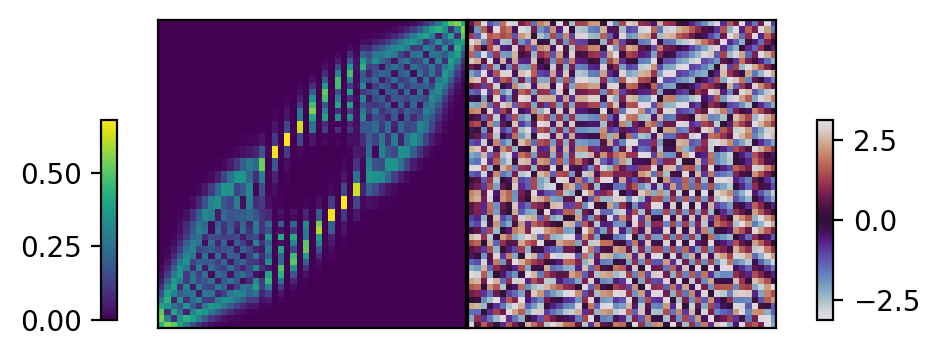

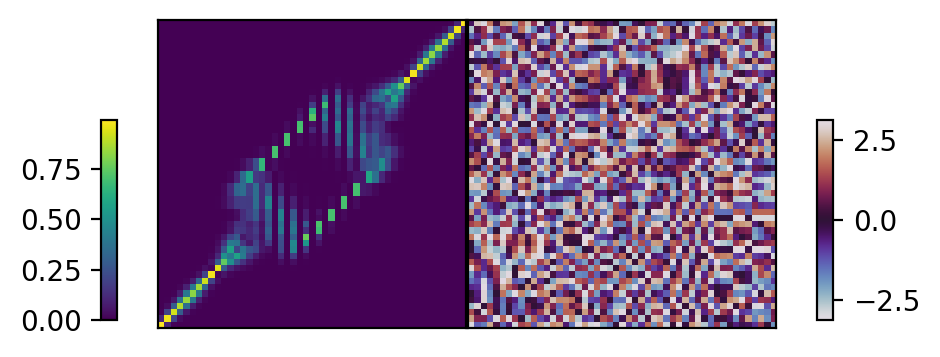

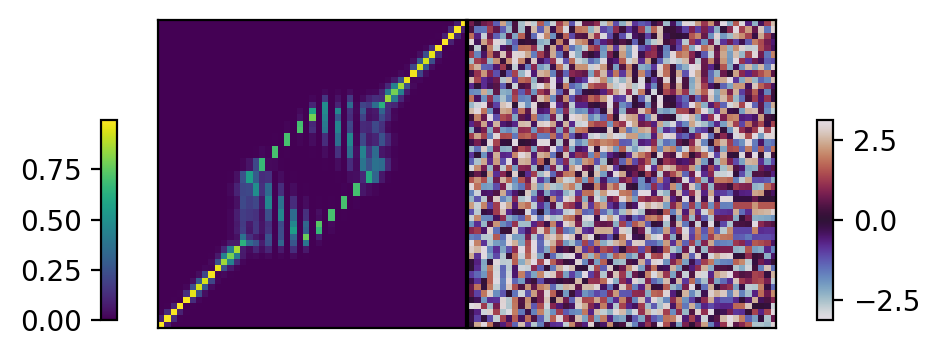

In [50]:
n=49; a=1.0; eps=0.500; b=0; parms0 = np.array([a,b,eps])
nseries=100
d_a = 0.0; 
d_b = (2*np.pi/n)/20 ;   # only varying b 
d_eps = 0.0/(nseries-1); 
dparms = np.array([d_a,d_b,d_eps])
yy2   = h0_drift_class(n,parms0,dparms,nseries)

Tlin = np.array([20,200,400])

for i in range(len(Tlin)):
    T = Tlin[i]; ntau =500
    yy2.compute_U2(T,ntau)
    t_matrix,p_matrix = comp_trans_h0(yy2)
    plt2_trans(t_matrix,p_matrix,'')

In [ ]:
# I think these are ok and as expected 

parms_final [1.        0.0961712 0.5      ]
a_init=1.000000, b_init=0.032057, eps_init=0.500000
a_final=1.000000, b_final=0.096171, eps_final=0.500000


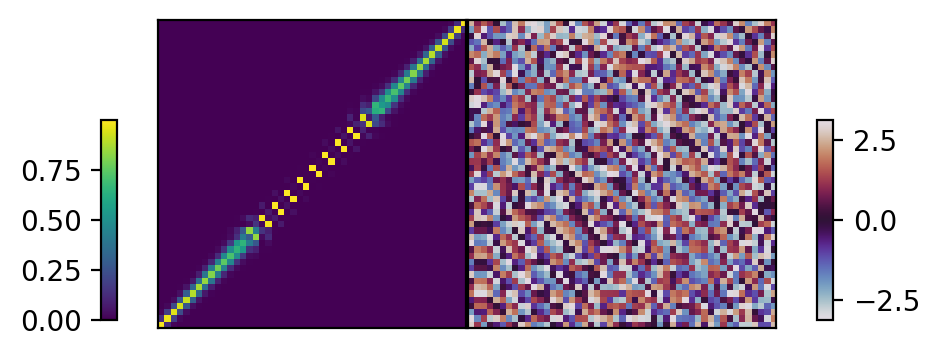

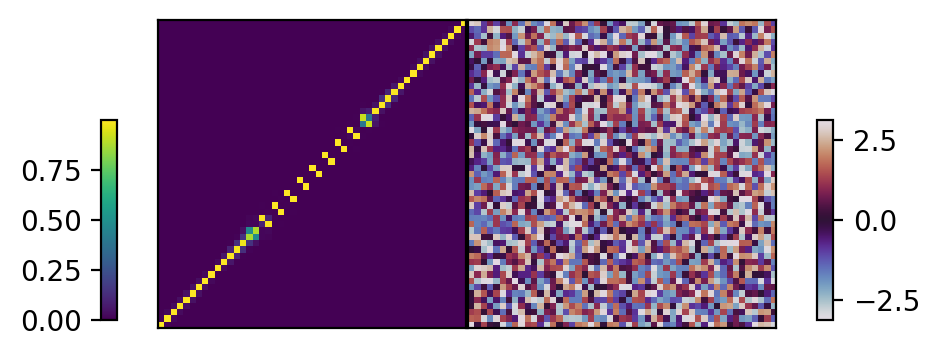

In [51]:
# only varying b 
# if only b varies, then energy levels in librating region slightly oscillate but those
# in circulating region move around and transition diabatically. 

n=49; a=1.0; eps=0.500; b=0.5*np.pi/n; parms0 = np.array([a,b,eps])
nseries=100
d_a = 0.0; 
d_b = (np.pi/n)/(nseries-1) ;  
d_eps = 0.0/(nseries-1); 
dparms = np.array([d_a,d_b,d_eps])
yy2   = h0_drift_class(n,parms0,dparms,nseries)

Tlin = np.array([20,200])

for i in range(len(Tlin)):
    T = Tlin[i]; ntau =500
    yy2.compute_U2(T,ntau)
    t_matrix,p_matrix = comp_trans_h0(yy2)
    plt2_trans(t_matrix,p_matrix,'')

distance between energy levels in librating region seems to be about 0.08
But the drift rate seems irrelevant 
Energy levels are not really changing in the librating regions
So why are we seeing transitions?

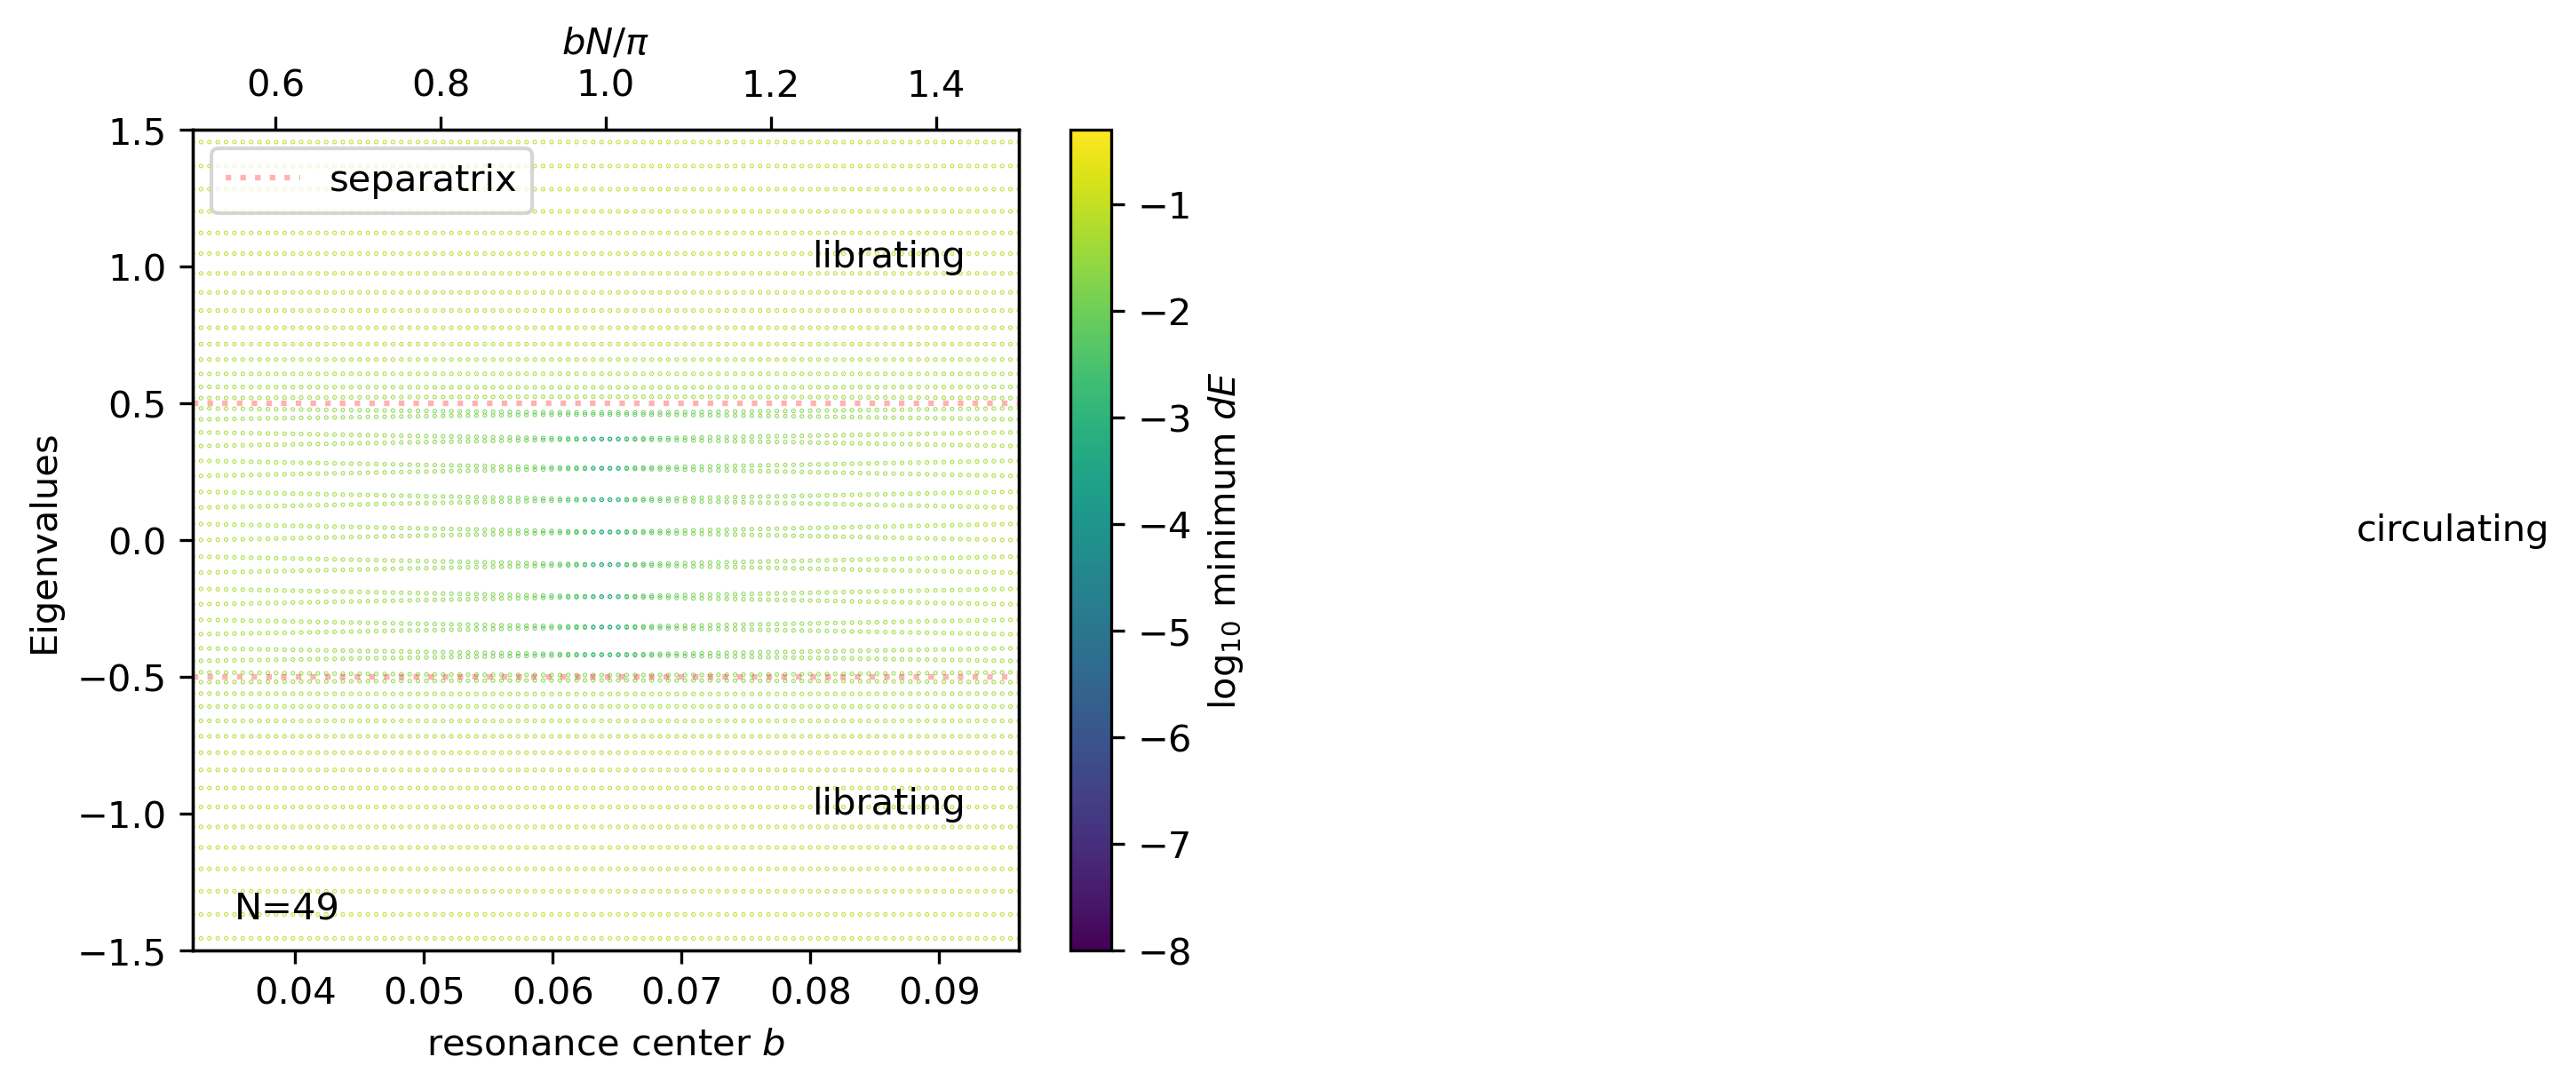

In [285]:

ymin = -1.5; ymax = 1.5
show_eigs(yy2,0,nseries,ymin,ymax,'')
# energy levels in librating regions don't change so there should not be any diabatic transitions 
# we are in the adiabatic limit 